In [3]:
import numpy as np
import scipy as sp
from scipy.linalg import block_diag
from scipy.stats import unitary_group
from qutip import *
np.set_printoptions(legacy='1.13',linewidth=np.inf, threshold=np.inf, precision=3)

import matplotlib.pyplot as plt

In [30]:
#Gibbs energy dist from beta = 1 case, from the RSJJ model calculation value, single mode coup 1 gamma 1.4
Gibbs = np.array([[0.58412,0,0],[0,0.278235,0],[0,0,0.137646]])
degeneracy = np.array([4,4,4])

#Gibbs state with the degeneracy (Ergodic restriction concerned)
def degen_Gibbs_create(Gib, deg, TF):
    dim = Gib.shape[0]
    
    if dim == len(deg):
        sys_gibbs = []
        for i in range(dim):
        ###### debug ######
            #print(Gibbs[i][i])
            #print(degeneracy[i])
            #print("----------")
        ###### debug ######
            temp = (Gib[i][i], deg[i])
            div = temp[0]/temp[1]

            make_matrix_dim = np.identity(temp[1])
            make_matrix_dim *= div
            
            sys_gibbs.append(make_matrix_dim)
            ###### debug ######
            #print(sys_gibbs)
            ###### debug ######
        ret_matrix = block_diag(*sys_gibbs)
        if TF == False:
            return ret_matrix
        if TF == True:
            return sys_gibbs

    else:
        print("Not available input source")
        return None 

In [31]:
Cal_Gibbs = degen_Gibbs_create(Gibbs,degeneracy,False)
Cal_Gibbs

array([[ 0.146,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.146,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.146,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.146,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ,  0.07 ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.07 ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.07 ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.07 ,  0.   ,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.034,  0.   ,  0.   ,  0.   ],
       [ 0.   ,  0.   ,  0.   ,  0.   ,  0.   ,  0.   ,

In [32]:
#Create Qubit system with coherence
asdf = coherent_dm(2,0.8j)
Sys_block = asdf.full()

gamma = np.sqrt(Sys_block[0][0]/Sys_block[1][1])

In [33]:
#System construction, False case
Nup_asdf_qobj = Qobj(Sys_block)
Cal_Gibbs_qobj = Qobj(Cal_Gibbs)
rhoRS_qutip = tensor(Nup_asdf_qobj, Cal_Gibbs_qobj)
rhoRS=rhoRS_qutip.full()

print(np.trace(rhoRS))

(1.000001+0j)


In [34]:
#avliable only for qubit condition
def Unit_block_diag_compose(sys,bath,gamma,rati):
    sys_index = (sys.shape[0])
    bath_index = len(bath)
    
    gamma_rati = np.sqrt(1-gamma**rati)

    #print("system_index",sys_index)

    index_comb = []

    for i in range(sys_index):
        for j in range(bath_index):
            comb = ((i,i),j)
            index_comb.append(comb)

    sorted_comb = sorted(index_comb, key=lambda x: x[0][0] + x[1])
    avail_values = [sorted_comb[i][0][0] + sorted_comb[i][1] for i in range(len(sorted_comb))] #possible combinations for indices corresponding energy conditions

    value_bound = (min(avail_values),max(avail_values))
    print("limited values : ", value_bound)

    avail_values = avail_values[1:-1]
    sorted_comb = sorted_comb[1:-1]
    print("sorted result : ",sorted_comb)
    print("avail_values : ",avail_values)

    ### zone divided structure construct ##
    sub_block_arr = []
    for k in range(len(sorted_comb)):
        sub_block = np.zeros(bath[sorted_comb[k][1]].shape[0])
        # This condition only acts under qubit case
        #print(sys[sorted_comb[k][0][0],sorted_comb[k][0][1]])
        sub_block = np.zeros((bath[sorted_comb[k][1]].shape[0],bath[sorted_comb[k][1]].shape[0]))
        sub_block_arr.append(sub_block)
    print("block divided zones")           
    print(sub_block_arr)
    #print(len(sub_block_arr))

    arrsize = 0 
    for l in range(len(sub_block_arr)):
        arrsize += sub_block_arr[l].shape[0]

    total_block = np.zeros((arrsize,arrsize),dtype=np.complex128)
#create_unitary subblock이 아니라 이 절차를 거칠 경우 유니터리에 의한 대각성분이 1이 나오는 것을 확인 가능.
    #row_offset = 0
    #col_offset = 0

    #for sub_block in sub_block_arr:
        #size = sub_block.shape[0]
        #total_block[row_offset:row_offset+size, col_offset:col_offset+size] = sub_block
        #row_offset += size
        #col_offset += size

    #create unitary subblock
    for i in range(0,len(sub_block_arr),sys_index):
        si = sub_block_arr[i].shape[0]
        sector_block_1 = np.zeros((si+1,si+1))
        sector_block_2 = np.zeros((si+1,si+1))

        sector_block_1[0][si] = 1
        sector_block_1[si][0] = 1

        sector_block_2[0][0] = gamma
        sector_block_2[si][si] = gamma
        sector_block_2[0][si] = gamma_rati
        sector_block_2[si][0] = -gamma_rati

        sec1 = sector_block_1.shape[0]
        sec2 = sector_block_2.shape[0]

        for i in range(total_block.shape[0]):
            for j in range(total_block.shape[0]):
                if i==j:
                    if j < 2:
                        total_block[i:i+sec1,j:j+sec1] = sector_block_1
                    elif 2 <= j < sec1-1:
                        total_block[i:i+sec2,j:j+sec2] = sector_block_2
                    elif j>=1 + sec2:
                        total_block[i][j] = 1

    print(total_block)
    #total_block = np.block([[block00,np.zeros((block00.shape[0],block00.shape[0]))],[np.zeros((block00.shape[0],block00.shape[0])),block11]])

    return total_block

limited values :  (0, 3)
sorted result :  [((0, 0), 1), ((1, 1), 0), ((0, 0), 2), ((1, 1), 1)]
avail_values :  [1, 1, 2, 2]
block divided zones
[array([[ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.]]), array([[ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.]]), array([[ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.]]), array([[ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.],
       [ 0.,  0.,  0.,  0.]])]
[[ 0.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j  1.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j]
 [ 0.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j  1.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j  0.000+0.j]
 [ 0.000+0.j  0.000+0.j  

C:\Users\sky12\AppData\Local\Temp\ipykernel_33784\1821765405.py:64: ComplexWarning: Casting complex values to real discards the imaginary part
  sector_block_2[0][0] = gamma
C:\Users\sky12\AppData\Local\Temp\ipykernel_33784\1821765405.py:65: ComplexWarning: Casting complex values to real discards the imaginary part
  sector_block_2[si][si] = gamma
C:\Users\sky12\AppData\Local\Temp\ipykernel_33784\1821765405.py:66: ComplexWarning: Casting complex values to real discards the imaginary part
  sector_block_2[0][si] = gamma_rati
C:\Users\sky12\AppData\Local\Temp\ipykernel_33784\1821765405.py:67: ComplexWarning: Casting complex values to real discards the imaginary part
  sector_block_2[si][0] = -gamma_rati


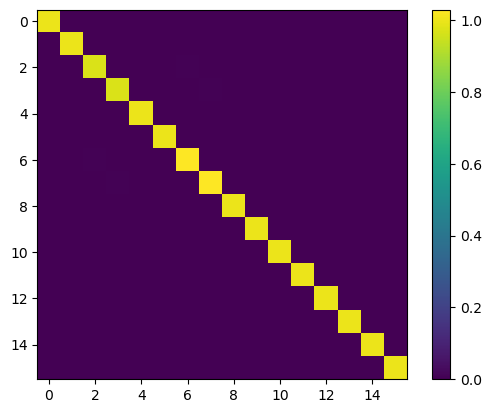

In [35]:
Cal_Gibbs_T = degen_Gibbs_create(Gibbs,degeneracy,True)
testbed = Unit_block_diag_compose(Sys_block,Cal_Gibbs_T,gamma,1)
c_testbed = testbed.conj().T
product = np.dot(testbed,c_testbed)

plt.imshow(product.real)
plt.colorbar()